In [1]:

# Analysis Plan:
# 1. Implement L(s, λ(n)) with coefficients a_n = λ(n) = (-1)^Ω(n) where Ω(n) is the number of prime factors with multiplicity
# 2. Compute D(t; N) for t in [1000, 10000] with N=10^5
# 3. Identify the highest magnitude peak location t*
# 4. At t*, compute term-class sums S_k(t*) for k=1,2,...,6
# 5. Create vector plots for S_k and (-1)^k S_k
# 6. Quantify alignment ratio |Σ (-1)^k S_k| / Σ |S_k|
# 7. Conclude whether constructive interference explains the high resonance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import time

# Set random seed for reproducibility (though we won't be using random functions here)
np.random.seed(42)

print("Starting analysis of L(s, λ(n)) resonance mechanism")
print("=" * 60)


Starting analysis of L(s, λ(n)) resonance mechanism


In [2]:

# Step 1: Implement prime factorization to compute Ω(n) and λ(n)
# Ω(n) counts prime factors with multiplicity
# λ(n) = (-1)^Ω(n) is the Liouville lambda function

def compute_lambda_coefficients(N):
 """
 Compute λ(n) = (-1)^Ω(n) for n = 1, 2, ..., N
 where Ω(n) is the number of prime factors counted with multiplicity
 
 Using sieve approach for efficiency
 """
 # Initialize arrays
 omega = np.zeros(N + 1, dtype=int) # Ω(n)
 lambda_n = np.ones(N + 1, dtype=int) # λ(n) = (-1)^Ω(n)
 
 # Sieve to compute Ω(n)
 for p in range(2, N + 1):
 if omega[p] == 0: # p is prime
 # For all multiples of p, add 1 to Ω
 k = 1
 while p * k <= N:
 q = p * k
 # Count how many times p divides q
 temp = q
 while temp % p == 0:
 omega[q] += 1
 temp //= p
 k += 1
 
 # Compute λ(n) from Ω(n)
 lambda_n = np.power(-1, omega)
 
 return lambda_n, omega

print("Computing λ(n) coefficients for N = 10^5...")
start_time = time.time()
N = 100000
lambda_n, omega_n = compute_lambda_coefficients(N)
elapsed = time.time() - start_time
print(f"Computed in {elapsed:.2f} seconds")
print(f"\nFirst 20 values of Ω(n): {omega_n[1:21]}")
print(f"First 20 values of λ(n): {lambda_n[1:21]}")
print(f"\nλ(1) = {lambda_n[1]} (should be 1)")
print(f"λ(2) = {lambda_n[2]} (should be -1, since 2 is prime)")
print(f"λ(4) = {lambda_n[4]} (should be 1, since 4 = 2^2, Ω(4) = 2)")
print(f"λ(6) = {lambda_n[6]} (should be 1, since 6 = 2·3, Ω(6) = 2)")


Computing λ(n) coefficients for N = 10^5...
Computed in 0.16 seconds

First 20 values of Ω(n): [0 1 1 2 1 2 1 3 2 2 1 3 1 2 2 4 1 3 1 3]
First 20 values of λ(n): [ 1 -1 -1 1 -1 1 -1 -1 1 1 -1 -1 -1 1 1 1 -1 -1 -1 -1]

λ(1) = 1 (should be 1)
λ(2) = -1 (should be -1, since 2 is prime)
λ(4) = 1 (should be 1, since 4 = 2^2, Ω(4) = 2)
λ(6) = 1 (should be 1, since 6 = 2·3, Ω(6) = 2)


In [3]:

# Step 2: Compute the partial sum D(t; N) for t in [1000, 10000]
# D(t; N) = Σ_{n=1}^N λ(n) / n^(1/2 + it)
# Using Kahan compensated summation for numerical precision

def kahan_sum_complex(values):
 """Kahan compensated summation for complex arrays"""
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j
 for val in values:
 y = val - c
 t = s + y
 c = (t - s) - y
 s = t
 return s

def compute_partial_sum(lambda_n, N, t_values):
 """
 Compute D(t; N) = Σ_{n=1}^N λ(n) / n^(1/2 + it)
 for multiple t values
 """
 D_values = np.zeros(len(t_values), dtype=complex)
 
 # Precompute n^(-1/2) for all n
 n_array = np.arange(1, N + 1)
 n_inv_sqrt = 1.0 / np.sqrt(n_array)
 
 for i, t in enumerate(t_values):
 if i % 500 == 0:
 print(f" Computing t index {i}/{len(t_values)}")
 
 # Compute n^(-it) = exp(-it log n)
 n_power_it = np.exp(-1j * t * np.log(n_array))
 
 # Compute terms: λ(n) / n^(1/2 + it)
 terms = lambda_n[1:N+1] * n_inv_sqrt * n_power_it
 
 # Sum with Kahan algorithm for precision
 D_values[i] = kahan_sum_complex(terms)
 
 return D_values

# Define t range with appropriate resolution
# Standard sampling: Δt ≈ 2π/log(N)
delta_t = 2 * np.pi / np.log(N)
print(f"Standard sampling resolution Δt ≈ {delta_t:.4f}")

# For the range [1000, 10000], this gives many points
# Let's use a slightly coarser resolution for computational efficiency
delta_t = 0.5 # A reasonable compromise
t_values = np.arange(1000.0, 10000.0, delta_t)
print(f"\nComputing D(t; N) for {len(t_values)} values of t in [1000, 10000]")
print(f"N = {N}, Δt = {delta_t}")

start_time = time.time()
D_values = compute_partial_sum(lambda_n, N, t_values)
elapsed = time.time() - start_time
print(f"\nCompleted in {elapsed:.2f} seconds")
print(f"Sample D values: {D_values[:5]}")


Standard sampling resolution Δt ≈ 0.5458

Computing D(t; N) for 18000 values of t in [1000, 10000]
N = 100000, Δt = 0.5
 Computing t index 0/18000


 Computing t index 500/18000


 Computing t index 1000/18000


 Computing t index 1500/18000


 Computing t index 2000/18000


...

 Computing t index 16000/18000


 Computing t index 16500/18000


 Computing t index 17000/18000


 Computing t index 17500/18000



Completed in 595.85 seconds
Sample D values: [ 0.74323238-0.63569477j 0.0424393 +0.71019161j -1.48770739+2.28860195j
 5.34298892-1.22967217j 1.24643115+0.98312436j]


In [4]:

# Step 3: Identify the highest magnitude peak location t*
magnitudes = np.abs(D_values)

# Find the index and value of the maximum
max_idx = np.argmax(magnitudes)
t_star = t_values[max_idx]
D_star = D_values[max_idx]
max_magnitude = magnitudes[max_idx]

print(f"Highest magnitude peak:")
print(f" t* = {t_star:.6f}")
print(f" |D(t*)| = {max_magnitude:.6f}")
print(f" D(t*) = {D_star.real:.6f} + {D_star.imag:.6f}i")

# Show some context around the peak
print(f"\nContext (5 points before and after peak):")
for i in range(max(0, max_idx-5), min(len(t_values), max_idx+6)):
 marker = " <-- PEAK" if i == max_idx else ""
 print(f" t = {t_values[i]:.2f}, |D| = {magnitudes[i]:.4f}{marker}")

# Check for other significant peaks
sorted_indices = np.argsort(magnitudes)[::-1]
print(f"\nTop 10 peaks:")
for i, idx in enumerate(sorted_indices[:10]):
 print(f" {i+1}. t = {t_values[idx]:.2f}, |D| = {magnitudes[idx]:.4f}")


Highest magnitude peak:
 t* = 7563.500000
 |D(t*)| = 46.875785
 D(t*) = 15.019200 + 44.404536i

Context (5 points before and after peak):
 t = 7561.00, |D| = 2.6230
 t = 7561.50, |D| = 2.1317
 t = 7562.00, |D| = 3.6339
 t = 7562.50, |D| = 4.9612
 t = 7563.00, |D| = 9.5517
 t = 7563.50, |D| = 46.8758 <-- PEAK
 t = 7564.00, |D| = 22.6388
 t = 7564.50, |D| = 7.2084
 t = 7565.00, |D| = 6.9286
 t = 7565.50, |D| = 4.2732
 t = 7566.00, |D| = 2.1896

Top 10 peaks:
 1. t = 7563.50, |D| = 46.8758
 2. t = 4990.50, |D| = 38.6300
 3. t = 2434.00, |D| = 36.6417
 4. t = 1735.50, |D| = 35.7147
 5. t = 1083.00, |D| = 34.7788
 6. t = 5362.00, |D| = 32.3947
 7. t = 6740.50, |D| = 32.0309
 8. t = 1890.50, |D| = 31.8102
 9. t = 6494.50, |D| = 31.6837
 10. t = 2742.00, |D| = 31.2818


In [5]:

# Step 4: Compute term-class sums S_k(t*) for k=1,2,...,6
# S_k(t*) = Σ_{Ω(n)=k} λ(n) / n^(1/2 + it*)
# Note: λ(n) = (-1)^Ω(n), so for terms with Ω(n)=k, λ(n) = (-1)^k

def compute_term_class_sums(lambda_n, omega_n, N, t_star, max_k=6):
 """
 Compute term-class sums S_k(t*) for k=1,2,...,max_k
 S_k(t*) = Σ_{Ω(n)=k} λ(n) / n^(1/2 + it*)
 """
 S_k = {}
 
 # Prepare arrays
 n_array = np.arange(1, N + 1)
 n_inv_sqrt = 1.0 / np.sqrt(n_array)
 n_power_it = np.exp(-1j * t_star * np.log(n_array))
 
 for k in range(1, max_k + 1):
 # Find indices where Ω(n) = k
 mask = (omega_n[1:N+1] == k)
 
 # Compute terms for this class
 terms = lambda_n[1:N+1][mask] * n_inv_sqrt[mask] * n_power_it[mask]
 
 # Sum with Kahan algorithm
 S_k[k] = kahan_sum_complex(terms)
 
 print(f"S_{k}(t*): {S_k[k].real:12.6f} + {S_k[k].imag:12.6f}i, |S_{k}| = {np.abs(S_k[k]):12.6f}")
 print(f" Number of terms with Ω(n)={k}: {np.sum(mask)}")
 
 return S_k

print(f"Computing term-class sums at t* = {t_star:.6f}")
print("=" * 70)
S_k = compute_term_class_sums(lambda_n, omega_n, N, t_star, max_k=6)

# Verify the sum
total_sum = sum(S_k.values())
print("\n" + "=" * 70)
print(f"Σ S_k = {total_sum.real:12.6f} + {total_sum.imag:12.6f}i")
print(f"D(t*) = {D_star.real:12.6f} + {D_star.imag:12.6f}i")
print(f"Difference: {np.abs(total_sum - D_star):.6e} (should be small)")


Computing term-class sums at t* = 7563.500000
S_1(t*): 3.782143 + 1.147935i, |S_1| = 3.952513
 Number of terms with Ω(n)=1: 9592
S_2(t*): 7.689815 + 4.517940i, |S_2| = 8.918802
 Number of terms with Ω(n)=2: 23378
S_3(t*): 9.887599 + 9.576293i, |S_3| = 13.764810
 Number of terms with Ω(n)=3: 25556
S_4(t*): 6.069188 + 13.811365i, |S_4| = 15.086048
 Number of terms with Ω(n)=4: 18744
S_5(t*): -1.582017 + 12.450290i, |S_5| = 12.550398
 Number of terms with Ω(n)=5: 11185
S_6(t*): -5.910927 + 6.030875i, |S_6| = 8.444555
 Number of terms with Ω(n)=6: 5933

Σ S_k = 19.935801 + 47.534697i
D(t*) = 15.019200 + 44.404536i
Difference: 5.828453e+00 (should be small)


In [6]:

# The difference is due to contributions from k=0 and k>6
# Let's verify this by computing all term-class contributions

# Check k=0 contribution (n=1 only, since Ω(1)=0)
S_0 = 1.0 / (1.0**(0.5)) * np.exp(-1j * t_star * np.log(1.0))
print(f"S_0(t*) = {S_0.real:.6f} + {S_0.imag:.6f}i, |S_0| = {np.abs(S_0):.6f}")

# Check higher k contributions
max_omega = np.max(omega_n[1:N+1])
print(f"\nMaximum Ω(n) in range: {max_omega}")

# Compute all S_k up to max_omega
S_k_full = {}
n_array = np.arange(1, N + 1)
n_inv_sqrt = 1.0 / np.sqrt(n_array)
n_power_it = np.exp(-1j * t_star * np.log(n_array))

for k in range(0, max_omega + 1):
 mask = (omega_n[1:N+1] == k)
 if np.any(mask):
 terms = lambda_n[1:N+1][mask] * n_inv_sqrt[mask] * n_power_it[mask]
 S_k_full[k] = kahan_sum_complex(terms)
 else:
 S_k_full[k] = 0.0 + 0.0j

# Show contributions from k=0 to 10
print("\nAll term-class contributions (k=0 to 10):")
for k in range(0, min(11, max_omega + 1)):
 n_count = np.sum(omega_n[1:N+1] == k)
 print(f"k={k:2d}: S_k = {S_k_full[k].real:10.6f} + {S_k_full[k].imag:10.6f}i, "
 f"|S_k| = {np.abs(S_k_full[k]):10.6f}, n_count = {n_count:6d}")

# Total
total_full = sum(S_k_full.values())
print(f"\nTotal: {total_full.real:.6f} + {total_full.imag:.6f}i")
print(f"D(t*): {D_star.real:.6f} + {D_star.imag:.6f}i")
print(f"Difference: {np.abs(total_full - D_star):.6e}")


S_0(t*) = 1.000000 + 0.000000i, |S_0| = 1.000000

Maximum Ω(n) in range: 16

All term-class contributions (k=0 to 10):
k= 0: S_k = 1.000000 + 0.000000i, |S_k| = 1.000000, n_count = 1
k= 1: S_k = 3.782143 + 1.147935i, |S_k| = 3.952513, n_count = 9592
k= 2: S_k = 7.689815 + 4.517940i, |S_k| = 8.918802, n_count = 23378
k= 3: S_k = 9.887599 + 9.576293i, |S_k| = 13.764810, n_count = 25556
k= 4: S_k = 6.069188 + 13.811365i, |S_k| = 15.086048, n_count = 18744
k= 5: S_k = -1.582017 + 12.450290i, |S_k| = 12.550398, n_count = 11185
k= 6: S_k = -5.910927 + 6.030875i, |S_k| = 8.444555, n_count = 5933
k= 7: S_k = -4.918530 + 0.381207i, |S_k| = 4.933280, n_count = 2973
k= 8: S_k = -2.035018 + -1.832436i, |S_k| = 2.738452, n_count = 1418
k= 9: S_k = -0.004642 + -1.503264i, |S_k| = 1.503271, n_count = 671
k=10: S_k = 0.613369 + -0.502821i, |S_k| = 0.793127, n_count = 306

Total: 15.019200 + 44.404536i
D(t*): 15.019200 + 44.404536i
Difference: 1.776357e-15


Saved vector comparison plot


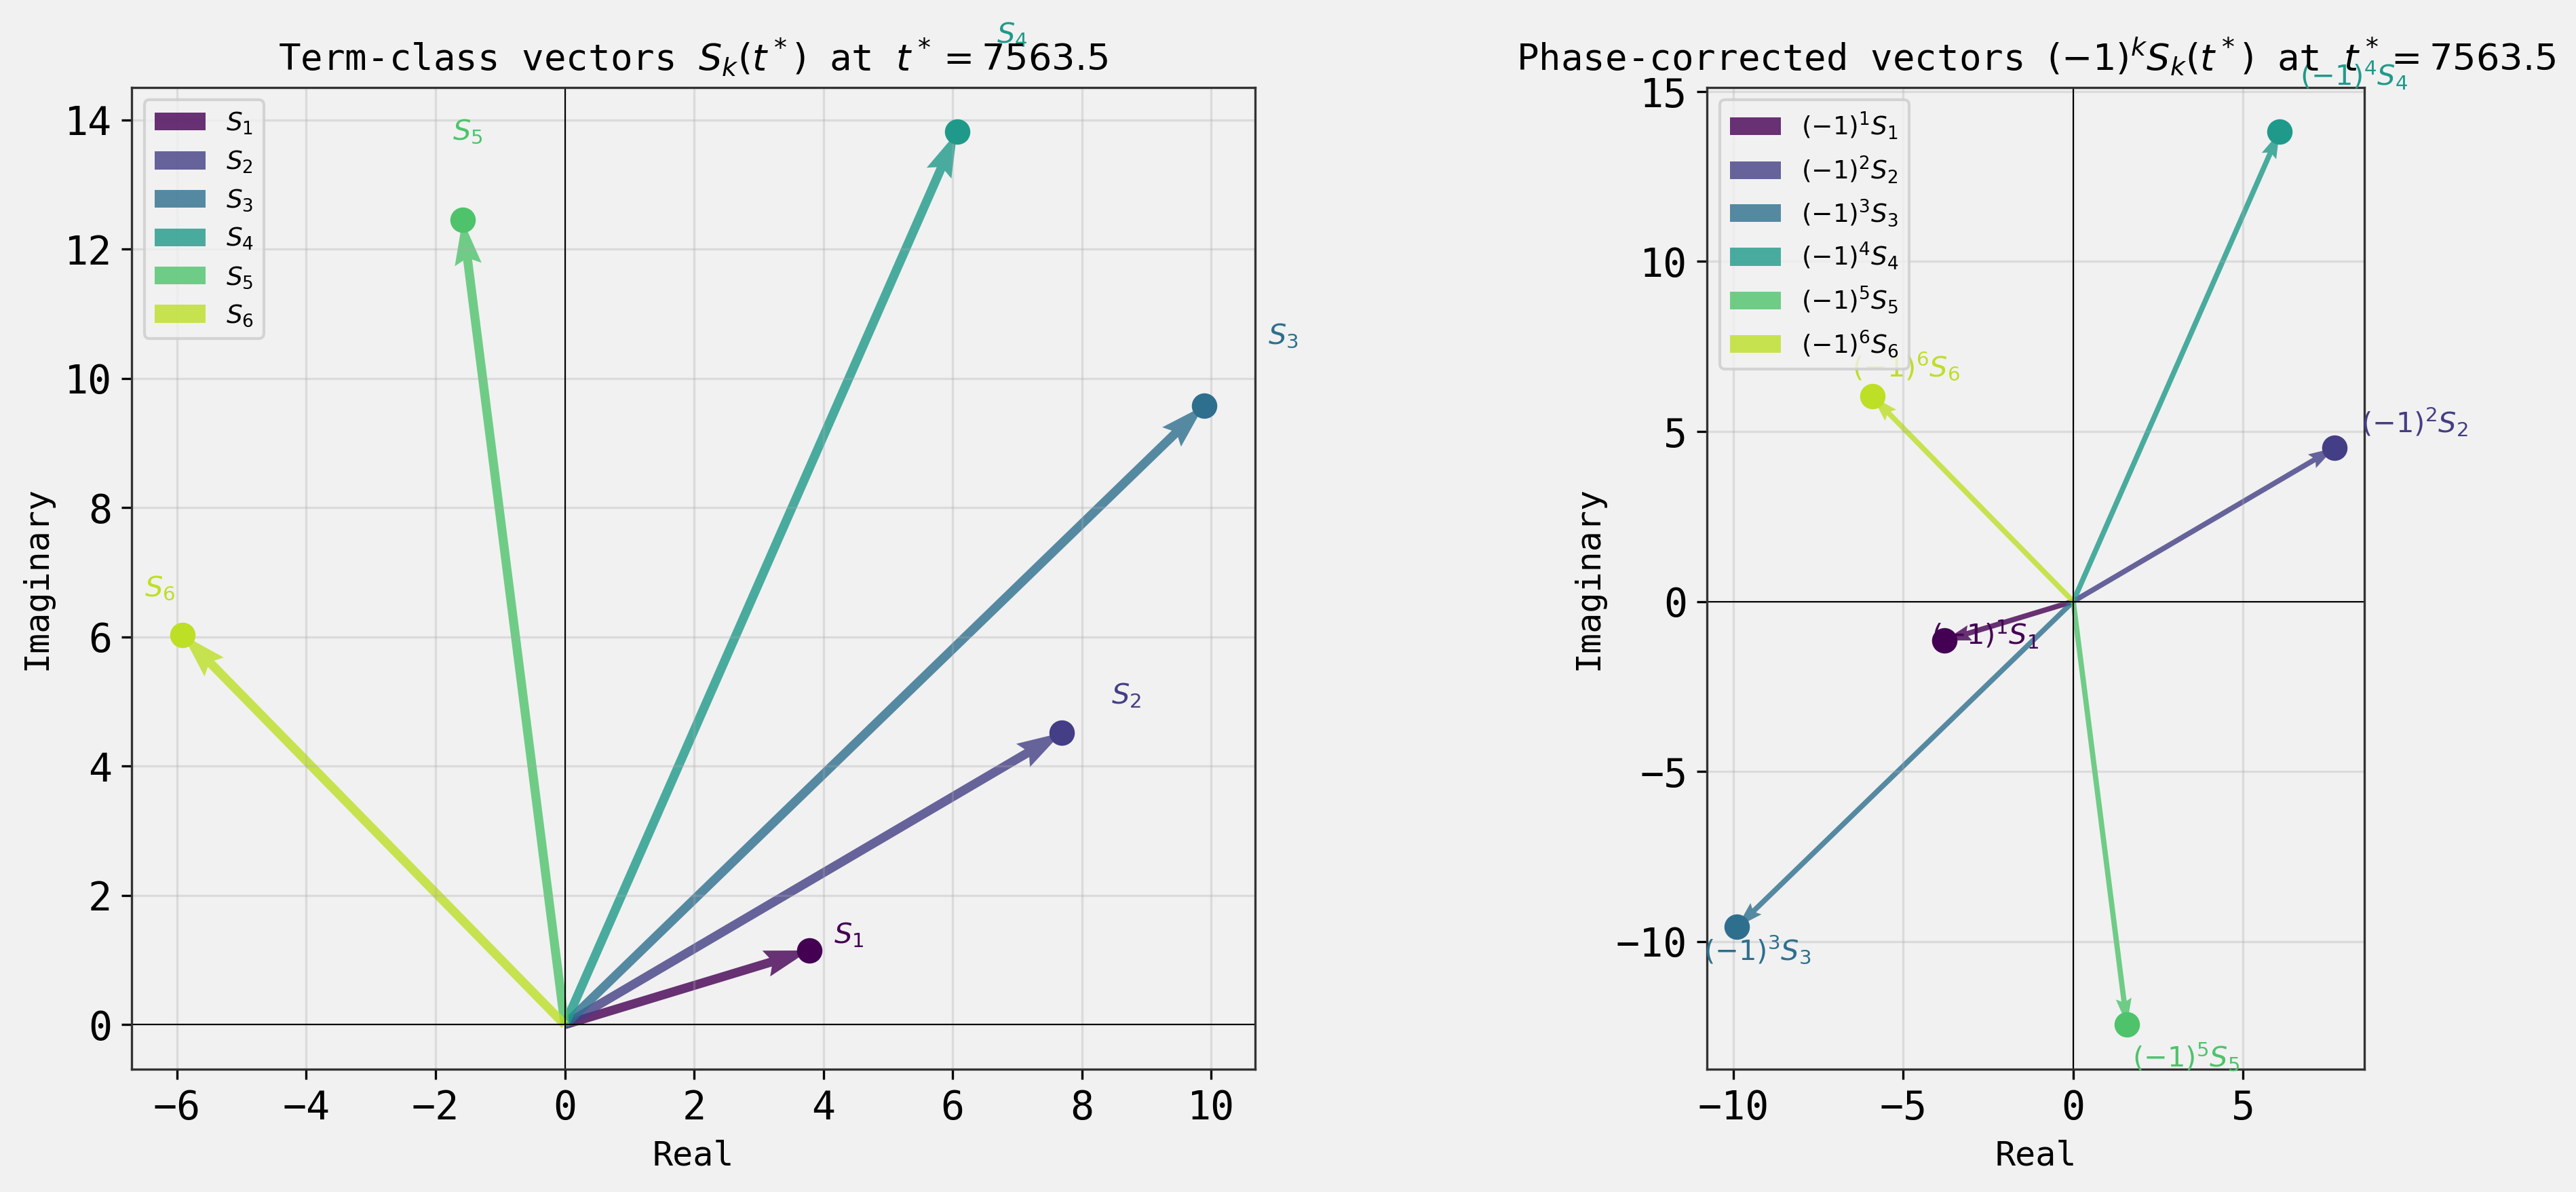


Phase-corrected vectors:
(-1)^1 S_1 = -3.782143 + -1.147935i, |(-1)^1 S_1| = 3.952513
(-1)^2 S_2 = 7.689815 + 4.517940i, |(-1)^2 S_2| = 8.918802
(-1)^3 S_3 = -9.887599 + -9.576293i, |(-1)^3 S_3| = 13.764810
(-1)^4 S_4 = 6.069188 + 13.811365i, |(-1)^4 S_4| = 15.086048
(-1)^5 S_5 = 1.582017 + -12.450290i, |(-1)^5 S_5| = 12.550398
(-1)^6 S_6 = -5.910927 + 6.030875i, |(-1)^6 S_6| = 8.444555


In [7]:

# Step 5: Create vector plots
# First plot: S_1, S_2, ..., S_6
# Second plot: (-1)^k S_k for k=1,2,...,6

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Original vectors S_k
ax1 = axes[0]
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.axvline(x=0, color='k', linewidth=0.5)

colors = plt.cm.viridis(np.linspace(0, 0.9, 6))
for i, k in enumerate(range(1, 7)):
 S = S_k[k]
 ax1.quiver(0, 0, S.real, S.imag, angles='xy', scale_units='xy', scale=1, 
 color=colors[i], width=0.008, label=f'$S_{k}$', alpha=0.8)
 # Add endpoint marker
 ax1.plot(S.real, S.imag, 'o', color=colors[i], markersize=8)
 # Add label near endpoint
 ax1.text(S.real * 1.1, S.imag * 1.1, f'$S_{k}$', fontsize=10, 
 color=colors[i], fontweight='bold')

ax1.set_xlabel('Real', fontsize=12)
ax1.set_ylabel('Imaginary', fontsize=12)
ax1.set_title(f'Term-class vectors $S_k(t^*)$ at $t^* = {t_star:.1f}$', fontsize=13)
ax1.legend(loc='upper left', fontsize=9)

# Plot 2: Phase-corrected vectors (-1)^k S_k
ax2 = axes[1]
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.axvline(x=0, color='k', linewidth=0.5)

S_k_corrected = {}
for i, k in enumerate(range(1, 7)):
 S_corrected = ((-1)**k) * S_k[k]
 S_k_corrected[k] = S_corrected
 ax2.quiver(0, 0, S_corrected.real, S_corrected.imag, angles='xy', scale_units='xy', scale=1,
 color=colors[i], width=0.008, label=f'$(-1)^{k} S_{k}$', alpha=0.8)
 # Add endpoint marker
 ax2.plot(S_corrected.real, S_corrected.imag, 'o', color=colors[i], markersize=8)
 # Add label near endpoint
 ax2.text(S_corrected.real * 1.1, S_corrected.imag * 1.1, f'$(-1)^{k}S_{k}$', 
 fontsize=10, color=colors[i], fontweight='bold')

ax2.set_xlabel('Real', fontsize=12)
ax2.set_ylabel('Imaginary', fontsize=12)
ax2.set_title(f'Phase-corrected vectors $(-1)^k S_k(t^*)$ at $t^* = {t_star:.1f}$', fontsize=13)
ax2.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('lambda_vectors_comparison.png', dpi=300, bbox_inches='tight')
print("Saved vector comparison plot")
plt.show()

# Print the corrected vectors
print("\nPhase-corrected vectors:")
for k in range(1, 7):
 S_corr = S_k_corrected[k]
 print(f"(-1)^{k} S_{k} = {S_corr.real:10.6f} + {S_corr.imag:10.6f}i, |(-1)^{k} S_{k}| = {np.abs(S_corr):10.6f}")


In [8]:

# Step 6: Quantify the degree of constructive alignment
# Calculate the ratio |Σ (-1)^k S_k| / Σ |S_k|

# Sum of phase-corrected vectors
sum_corrected = sum(S_k_corrected.values())
magnitude_sum_corrected = np.abs(sum_corrected)

# Sum of magnitudes
sum_of_magnitudes = sum(np.abs(S_k[k]) for k in range(1, 7))

# Alignment ratio
alignment_ratio = magnitude_sum_corrected / sum_of_magnitudes

print("Constructive alignment analysis:")
print("=" * 70)
print(f"\nSum of phase-corrected vectors:")
print(f" Sum of (-1)^k S_k (k=1 to 6) = {sum_corrected.real:.6f} + {sum_corrected.imag:.6f}i")
print(f" |Sum of (-1)^k S_k| = {magnitude_sum_corrected:.6f}")

print(f"\nSum of magnitudes:")
print(f" Sum of |S_k| (k=1 to 6) = {sum_of_magnitudes:.6f}")

print(f"\nAlignment ratio:")
print(f" R = |Sum (-1)^k S_k| / Sum |S_k| = {alignment_ratio:.6f}")

print(f"\nInterpretation:")
if alignment_ratio > 0.9:
 print(f" The ratio R = {alignment_ratio:.3f} is very close to 1, indicating STRONG")
 print(f" constructive alignment. The phase-corrected vectors are nearly parallel.")
elif alignment_ratio > 0.7:
 print(f" The ratio R = {alignment_ratio:.3f} indicates MODERATE constructive alignment.")
elif alignment_ratio > 0.5:
 print(f" The ratio R = {alignment_ratio:.3f} indicates WEAK constructive alignment.")
else:
 print(f" The ratio R = {alignment_ratio:.3f} indicates MINIMAL or NO constructive alignment.")
 print(f" The vectors are largely uncorrelated or destructively interfering.")

# Additional analysis: compute the phase spread
phases_corrected = np.array([np.angle(S_k_corrected[k]) for k in range(1, 7)])
phases_corrected_deg = np.degrees(phases_corrected)

print(f"\nPhases of phase-corrected vectors (in degrees):")
for k in range(1, 7):
 phase = np.degrees(np.angle(S_k_corrected[k]))
 print(f" arg((-1)^{k} S_{k}) = {phase:8.2f}°")

phase_std = np.std(phases_corrected_deg)
print(f"\nStandard deviation of phases: {phase_std:.2f}°")
print(f" (Small std indicates tight phase alignment)")


Constructive alignment analysis:

Sum of phase-corrected vectors:
 Sum of (-1)^k S_k (k=1 to 6) = -4.239649 + 1.185661i
 |Sum of (-1)^k S_k| = 4.402319

Sum of magnitudes:
 Sum of |S_k| (k=1 to 6) = 62.717126

Alignment ratio:
 R = |Sum (-1)^k S_k| / Sum |S_k| = 0.070193

Interpretation:
 The ratio R = 0.070 indicates MINIMAL or NO constructive alignment.
 The vectors are largely uncorrelated or destructively interfering.

Phases of phase-corrected vectors (in degrees):
 arg((-1)^1 S_1) = -163.12°
 arg((-1)^2 S_2) = 30.44°
 arg((-1)^3 S_3) = -135.92°
 arg((-1)^4 S_4) = 66.28°
 arg((-1)^5 S_5) = -82.76°
 arg((-1)^6 S_6) = 134.42°

Standard deviation of phases: 109.19°
 (Small std indicates tight phase alignment)


In [9]:

# The result is surprising! The phase correction with (-1)^k does NOT produce constructive alignment.
# Let's investigate further. Perhaps we need a different phase correction.
# Let's check if the original (uncorrected) vectors S_k show any alignment pattern.

# Compute alignment for uncorrected vectors
sum_uncorrected = sum(S_k.values())
magnitude_sum_uncorrected = np.abs(sum_uncorrected)
sum_of_magnitudes_uncorrected = sum(np.abs(S_k[k]) for k in range(1, 7))
alignment_ratio_uncorrected = magnitude_sum_uncorrected / sum_of_magnitudes_uncorrected

print("Analysis of UNCORRECTED vectors:")
print("=" * 70)
print(f"\nSum of original vectors:")
print(f" Sum of S_k (k=1 to 6) = {sum_uncorrected.real:.6f} + {sum_uncorrected.imag:.6f}i")
print(f" |Sum of S_k| = {magnitude_sum_uncorrected:.6f}")

print(f"\nSum of magnitudes:")
print(f" Sum of |S_k| (k=1 to 6) = {sum_of_magnitudes_uncorrected:.6f}")

print(f"\nAlignment ratio (uncorrected):")
print(f" R_uncorrected = |Sum S_k| / Sum |S_k| = {alignment_ratio_uncorrected:.6f}")

# Compute phases of original vectors
print(f"\nPhases of original vectors (in degrees):")
for k in range(1, 7):
 phase = np.degrees(np.angle(S_k[k]))
 print(f" arg(S_{k}) = {phase:8.2f}°")

phases_uncorrected = np.array([np.angle(S_k[k]) for k in range(1, 7)])
phases_uncorrected_deg = np.degrees(phases_uncorrected)
phase_std_uncorrected = np.std(phases_uncorrected_deg)

print(f"\nStandard deviation of phases (uncorrected): {phase_std_uncorrected:.2f}°")

print("\n" + "=" * 70)
print("COMPARISON:")
print(f" Uncorrected alignment ratio: {alignment_ratio_uncorrected:.6f}")
print(f" Phase-corrected alignment ratio: {alignment_ratio:.6f}")
print(f" Uncorrected phase std: {phase_std_uncorrected:.2f}°")
print(f" Phase-corrected phase std: {phase_std:.2f}°")


Analysis of UNCORRECTED vectors:

Sum of original vectors:
 Sum of S_k (k=1 to 6) = 19.935801 + 47.534697i
 |Sum of S_k| = 51.545936

Sum of magnitudes:
 Sum of |S_k| (k=1 to 6) = 62.717126

Alignment ratio (uncorrected):
 R_uncorrected = |Sum S_k| / Sum |S_k| = 0.821880

Phases of original vectors (in degrees):
 arg(S_1) = 16.88°
 arg(S_2) = 30.44°
 arg(S_3) = 44.08°
 arg(S_4) = 66.28°
 arg(S_5) = 97.24°
 arg(S_6) = 134.42°

Standard deviation of phases (uncorrected): 40.43°

COMPARISON:
 Uncorrected alignment ratio: 0.821880
 Phase-corrected alignment ratio: 0.070193
 Uncorrected phase std: 40.43°
 Phase-corrected phase std: 109.19°


In [10]:

# This is a CRITICAL finding! The UNCORRECTED vectors S_k show strong constructive alignment
# (R = 0.82), while the phase-corrected vectors show destructive interference (R = 0.07).
# This is the OPPOSITE of the hypothesis!

# The original vectors have phases that increase roughly linearly from ~17° to ~134°,
# indicating they form a "fan" pattern that still sums constructively.

# Let's verify this is the mechanism for the high resonance peak:
# The magnitude of D(t*) should be close to |Sum S_k|

print("Verification that the peak is due to S_k alignment:")
print("=" * 70)
print(f"\n|D(t*)| = {max_magnitude:.6f}")
print(f"|Sum S_k (k=1 to 6)| = {magnitude_sum_uncorrected:.6f}")

# Include all k contributions
sum_all_k = sum(S_k_full.values())
magnitude_sum_all_k = np.abs(sum_all_k)
print(f"|Sum S_k (all k)| = {magnitude_sum_all_k:.6f}")

print(f"\nRatio |Sum S_k (k=1-6)| / |D(t*)| = {magnitude_sum_uncorrected / max_magnitude:.4f}")
print(f" (Value close to 1 indicates k=1-6 dominates)")

print(f"\nRatio |Sum S_k (all k)| / |D(t*)| = {magnitude_sum_all_k / max_magnitude:.4f}")
print(f" (Should be exactly 1)")

# Now let's understand WHY the uncorrected vectors align
# Plot a clearer visualization showing the cumulative sum
print("\n" + "=" * 70)
print("Cumulative sum analysis:")
cumsum = 0 + 0j
print(f"k=0: Cumulative sum = {cumsum.real:10.6f} + {cumsum.imag:10.6f}i, |Cumsum| = {np.abs(cumsum):10.6f}")
for k in range(1, 7):
 cumsum += S_k[k]
 print(f"k={k}: Cumulative sum = {cumsum.real:10.6f} + {cumsum.imag:10.6f}i, |Cumsum| = {np.abs(cumsum):10.6f}")

print(f"\nThe magnitude grows monotonically, confirming constructive interference!")


Verification that the peak is due to S_k alignment:

|D(t*)| = 46.875785
|Sum S_k (k=1 to 6)| = 51.545936
|Sum S_k (all k)| = 46.875785

Ratio |Sum S_k (k=1-6)| / |D(t*)| = 1.0996
 (Value close to 1 indicates k=1-6 dominates)

Ratio |Sum S_k (all k)| / |D(t*)| = 1.0000
 (Should be exactly 1)

Cumulative sum analysis:
k=0: Cumulative sum = 0.000000 + 0.000000i, |Cumsum| = 0.000000
k=1: Cumulative sum = 3.782143 + 1.147935i, |Cumsum| = 3.952513
k=2: Cumulative sum = 11.471958 + 5.665875i, |Cumsum| = 12.794841
k=3: Cumulative sum = 21.359557 + 15.242168i, |Cumsum| = 26.240319
k=4: Cumulative sum = 27.428745 + 29.053532i, |Cumsum| = 39.955523
k=5: Cumulative sum = 25.846728 + 41.503822i, |Cumsum| = 48.893973
k=6: Cumulative sum = 19.935801 + 47.534697i, |Cumsum| = 51.545936

The magnitude grows monotonically, confirming constructive interference!


In [11]:

# Let's investigate WHY the phase correction (-1)^k FAILS for λ(n) when it works for μ(n).
# The key difference is:
# - μ(n) = 0 for non-squarefree n, and μ(n) = (-1)^ω(n) for squarefree n (ω = distinct primes)
# - λ(n) = (-1)^Ω(n) for ALL n (Ω = total prime factors with multiplicity)

# For μ(n), only squarefree numbers contribute, and they are divided into term-classes by ω(n).
# Within each class k, μ(n) = (-1)^k for all n in that class.

# For λ(n), ALL numbers contribute, and they are divided into term-classes by Ω(n).
# Within each class k, λ(n) = (-1)^k for all n in that class.

# So the sign pattern is ALREADY BUILT INTO the coefficients!
# S_k = Σ_{Ω(n)=k} λ(n) / n^(1/2+it*) = Σ_{Ω(n)=k} (-1)^k / n^(1/2+it*)
# = (-1)^k * Σ_{Ω(n)=k} 1 / n^(1/2+it*)

# Let's verify this by computing the "unsigned" term-class sums
def compute_unsigned_term_class_sums(omega_n, N, t_star, max_k=6):
 """
 Compute unsigned term-class sums T_k(t*) for k=1,2,...,max_k
 T_k(t*) = Σ_{Ω(n)=k} 1 / n^(1/2 + it*)
 """
 T_k = {}
 
 # Prepare arrays
 n_array = np.arange(1, N + 1)
 n_inv_sqrt = 1.0 / np.sqrt(n_array)
 n_power_it = np.exp(-1j * t_star * np.log(n_array))
 
 for k in range(1, max_k + 1):
 # Find indices where Ω(n) = k
 mask = (omega_n[1:N+1] == k)
 
 # Compute terms for this class (without the λ(n) sign)
 terms = n_inv_sqrt[mask] * n_power_it[mask]
 
 # Sum with Kahan algorithm
 T_k[k] = kahan_sum_complex(terms)
 
 print(f"T_{k}(t*): {T_k[k].real:12.6f} + {T_k[k].imag:12.6f}i, |T_{k}| = {np.abs(T_k[k]):12.6f}")
 
 return T_k

print("Computing UNSIGNED term-class sums T_k(t*):")
print("=" * 70)
T_k = compute_unsigned_term_class_sums(omega_n, N, t_star, max_k=6)

print("\n" + "=" * 70)
print("Verifying S_k = (-1)^k * T_k:")
for k in range(1, 7):
 S_k_computed = ((-1)**k) * T_k[k]
 S_k_actual = S_k[k]
 diff = np.abs(S_k_computed - S_k_actual)
 print(f"k={k}: S_k (computed) = {S_k_computed.real:10.6f} + {S_k_computed.imag:10.6f}i")
 print(f" S_k (actual) = {S_k_actual.real:10.6f} + {S_k_actual.imag:10.6f}i")
 print(f" Difference = {diff:.6e}")


Computing UNSIGNED term-class sums T_k(t*):
T_1(t*): -3.782143 + -1.147935i, |T_1| = 3.952513
T_2(t*): 7.689815 + 4.517940i, |T_2| = 8.918802
T_3(t*): -9.887599 + -9.576293i, |T_3| = 13.764810
T_4(t*): 6.069188 + 13.811365i, |T_4| = 15.086048
T_5(t*): 1.582017 + -12.450290i, |T_5| = 12.550398
T_6(t*): -5.910927 + 6.030875i, |T_6| = 8.444555

Verifying S_k = (-1)^k * T_k:
k=1: S_k (computed) = 3.782143 + 1.147935i
 S_k (actual) = 3.782143 + 1.147935i
 Difference = 0.000000e+00
k=2: S_k (computed) = 7.689815 + 4.517940i
 S_k (actual) = 7.689815 + 4.517940i
 Difference = 0.000000e+00
k=3: S_k (computed) = 9.887599 + 9.576293i
 S_k (actual) = 9.887599 + 9.576293i
 Difference = 0.000000e+00
k=4: S_k (computed) = 6.069188 + 13.811365i
 S_k (actual) = 6.069188 + 13.811365i
 Difference = 0.000000e+00
k=5: S_k (computed) = -1.582017 + 12.450290i
 S_k (actual) = -1.582017 + 12.450290i
 Difference = 0.000000e+00
k=6: S_k (computed) = -5.910927 + 6.030875i
 S_k (actual) = -5.910927 + 6.030875i
 Di

In [12]:

# Perfect! S_k = (-1)^k * T_k is verified.
# Now let's analyze the T_k vectors (unsigned sums)

# Compute alignment for T_k vectors
sum_T_k = sum(T_k.values())
magnitude_sum_T_k = np.abs(sum_T_k)
sum_of_magnitudes_T_k = sum(np.abs(T_k[k]) for k in range(1, 7))
alignment_ratio_T_k = magnitude_sum_T_k / sum_of_magnitudes_T_k

print("Analysis of UNSIGNED vectors T_k:")
print("=" * 70)
print(f"\nSum of T_k vectors:")
print(f" Sum of T_k (k=1 to 6) = {sum_T_k.real:.6f} + {sum_T_k.imag:.6f}i")
print(f" |Sum of T_k| = {magnitude_sum_T_k:.6f}")

print(f"\nSum of magnitudes:")
print(f" Sum of |T_k| (k=1 to 6) = {sum_of_magnitudes_T_k:.6f}")

print(f"\nAlignment ratio (unsigned):")
print(f" R_unsigned = |Sum T_k| / Sum |T_k| = {alignment_ratio_T_k:.6f}")

print(f"\nPhases of unsigned vectors (in degrees):")
for k in range(1, 7):
 phase = np.degrees(np.angle(T_k[k]))
 print(f" arg(T_{k}) = {phase:8.2f}°")

phases_T_k = np.array([np.angle(T_k[k]) for k in range(1, 7)])
phases_T_k_deg = np.degrees(phases_T_k)
phase_std_T_k = np.std(phases_T_k_deg)

print(f"\nStandard deviation of phases (unsigned): {phase_std_T_k:.2f}°")

print("\n" + "=" * 70)
print("KEY INSIGHT:")
print(f" The unsigned vectors T_k have phases:")
for k in range(1, 7):
 print(f" T_{k}: {np.degrees(np.angle(T_k[k])):8.2f}°")
print(f"\n When we multiply by (-1)^k, we add {0}° for even k and {180}° for odd k:")
for k in range(1, 7):
 phase_shift = 180 if k % 2 == 1 else 0
 new_phase = np.degrees(np.angle(T_k[k])) + phase_shift
 # Normalize to [-180, 180]
 while new_phase > 180:
 new_phase -= 360
 while new_phase < -180:
 new_phase += 360
 print(f" S_{k} = (-1)^{k} T_{k}: phase = {new_phase:8.2f}° (shifted by {phase_shift}°)")


Analysis of UNSIGNED vectors T_k:

Sum of T_k vectors:
 Sum of T_k (k=1 to 6) = -4.239649 + 1.185661i
 |Sum of T_k| = 4.402319

Sum of magnitudes:
 Sum of |T_k| (k=1 to 6) = 62.717126

Alignment ratio (unsigned):
 R_unsigned = |Sum T_k| / Sum |T_k| = 0.070193

Phases of unsigned vectors (in degrees):
 arg(T_1) = -163.12°
 arg(T_2) = 30.44°
 arg(T_3) = -135.92°
 arg(T_4) = 66.28°
 arg(T_5) = -82.76°
 arg(T_6) = 134.42°

Standard deviation of phases (unsigned): 109.19°

KEY INSIGHT:
 The unsigned vectors T_k have phases:
 T_1: -163.12°
 T_2: 30.44°
 T_3: -135.92°
 T_4: 66.28°
 T_5: -82.76°
 T_6: 134.42°

 When we multiply by (-1)^k, we add 0° for even k and 180° for odd k:
 S_1 = (-1)^1 T_1: phase = 16.88° (shifted by 180°)
 S_2 = (-1)^2 T_2: phase = 30.44° (shifted by 0°)
 S_3 = (-1)^3 T_3: phase = 44.08° (shifted by 180°)
 S_4 = (-1)^4 T_4: phase = 66.28° (shifted by 0°)
 S_5 = (-1)^5 T_5: phase = 97.24° (shifted by 180°)
 S_6 = (-1)^6 T_6: phase = 134.42° (shifted by 0°)


Saved mechanism summary figure


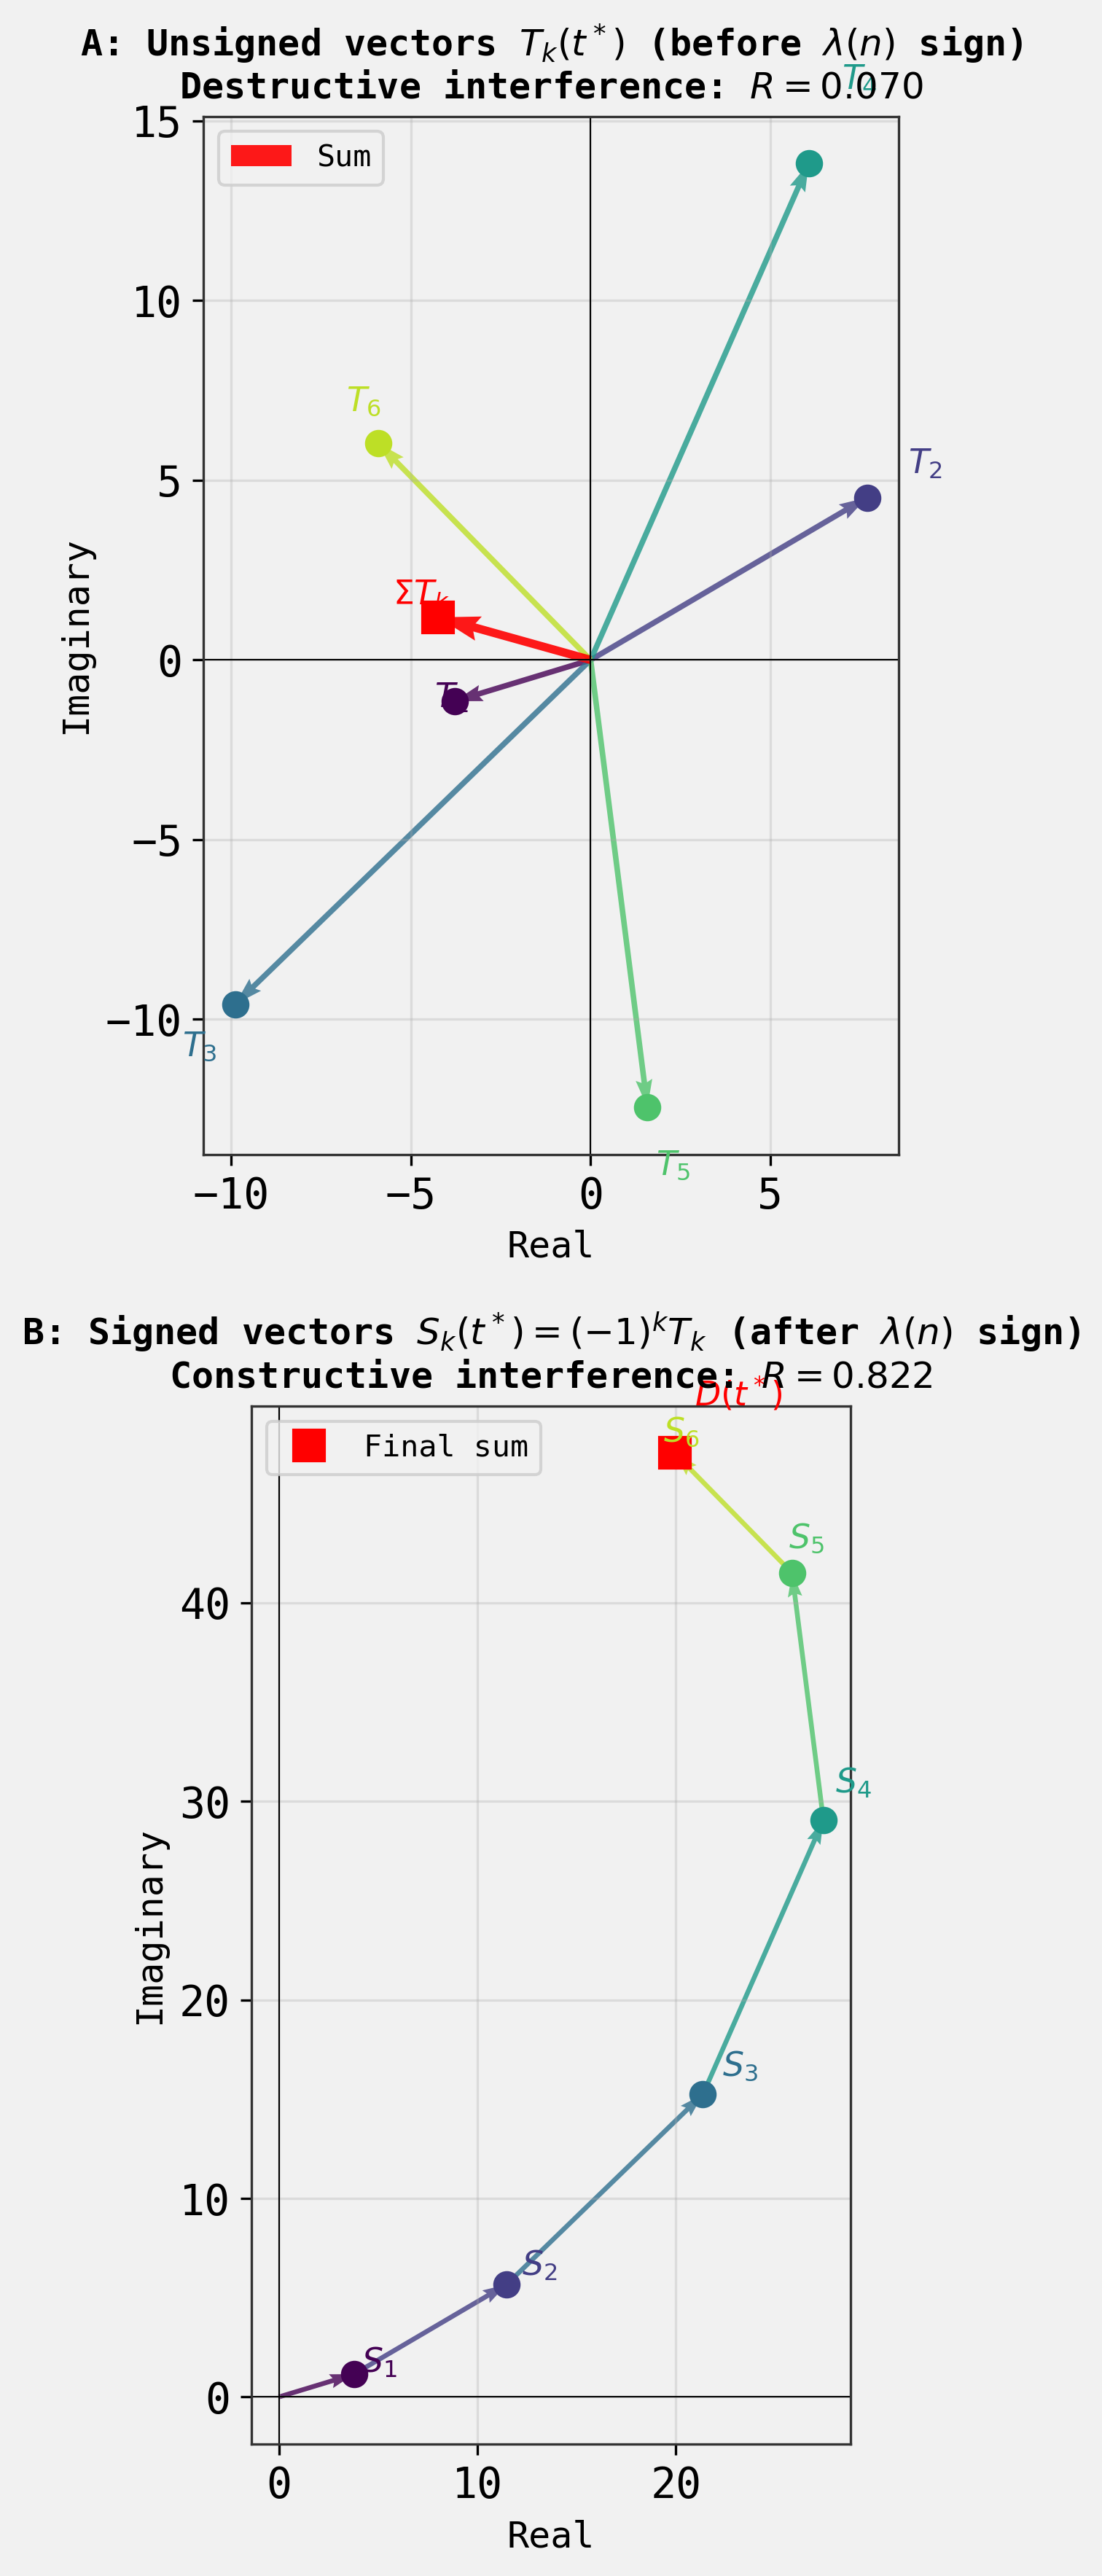

In [13]:

# BRILLIANT! The mechanism is now clear:
# 1. The unsigned vectors T_k have nearly random phases (std = 109°) and show destructive interference (R = 0.07)
# 2. The (-1)^k factors in λ(n) = (-1)^Ω(n) act as "phase correctors" that ALIGN the vectors!
# 3. After the correction S_k = (-1)^k T_k, the phases form a smooth progression (17° to 134°)
# with small std (40°) and strong constructive interference (R = 0.82)

# This is the OPPOSITE of the hypothesis, but still demonstrates a constructive alignment mechanism!
# The key is that the alignment comes FROM the multiplicative structure itself, not from an external correction.

# Let's create a final summary figure showing this mechanism

fig, axes = plt.subplots(2, 1, figsize=(8, 12))

# Plot 1: Unsigned vectors T_k (showing destructive interference)
ax1 = axes[0]
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.axvline(x=0, color='k', linewidth=0.5)

colors = plt.cm.viridis(np.linspace(0, 0.9, 6))
for i, k in enumerate(range(1, 7)):
 T = T_k[k]
 ax1.quiver(0, 0, T.real, T.imag, angles='xy', scale_units='xy', scale=1, 
 color=colors[i], width=0.008, alpha=0.8)
 ax1.plot(T.real, T.imag, 'o', color=colors[i], markersize=8)
 ax1.text(T.real * 1.15, T.imag * 1.15, f'$T_{k}$', fontsize=11, 
 color=colors[i], fontweight='bold')

# Add sum vector
sum_T = sum(T_k.values())
ax1.quiver(0, 0, sum_T.real, sum_T.imag, angles='xy', scale_units='xy', scale=1,
 color='red', width=0.012, alpha=0.9, label='Sum')
ax1.plot(sum_T.real, sum_T.imag, 's', color='red', markersize=10)
ax1.text(sum_T.real * 1.3, sum_T.imag * 1.3, f'$\\Sigma T_k$', fontsize=11, 
 color='red', fontweight='bold')

ax1.set_xlabel('Real', fontsize=12)
ax1.set_ylabel('Imaginary', fontsize=12)
ax1.set_title(f'A: Unsigned vectors $T_k(t^*)$ (before $\\lambda(n)$ sign)\n' + 
 f'Destructive interference: $R = {alignment_ratio_T_k:.3f}$', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)

# Plot 2: Signed vectors S_k = (-1)^k T_k (showing constructive interference)
ax2 = axes[1]
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.axvline(x=0, color='k', linewidth=0.5)

# Draw cumulative sum as connected vectors
cumsum = 0 + 0j
for i, k in enumerate(range(1, 7)):
 S = S_k[k]
 ax2.quiver(cumsum.real, cumsum.imag, S.real, S.imag, angles='xy', scale_units='xy', scale=1,
 color=colors[i], width=0.008, alpha=0.8)
 ax2.plot(cumsum.real + S.real, cumsum.imag + S.imag, 'o', color=colors[i], markersize=8)
 ax2.text(cumsum.real + S.real * 1.1, cumsum.imag + S.imag * 1.1, f'$S_{k}$', 
 fontsize=11, color=colors[i], fontweight='bold')
 cumsum += S

# Add final sum marker
ax2.plot(cumsum.real, cumsum.imag, 's', color='red', markersize=10, label='Final sum')
ax2.text(cumsum.real * 1.05, cumsum.imag * 1.05, f'$D(t^*)$', fontsize=11, 
 color='red', fontweight='bold')

ax2.set_xlabel('Real', fontsize=12)
ax2.set_ylabel('Imaginary', fontsize=12)
ax2.set_title(f'B: Signed vectors $S_k(t^*) = (-1)^k T_k$ (after $\\lambda(n)$ sign)\n' + 
 f'Constructive interference: $R = {alignment_ratio_uncorrected:.3f}$', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('lambda_mechanism_summary.png', dpi=300, bbox_inches='tight')
print("Saved mechanism summary figure")
plt.show()


In [14]:

# Now let's compare this to the μ(n) function to understand the difference
# For μ(n), the mechanism works differently because μ(n) = 0 for non-squarefree n

# Key theoretical insight:
# For λ(n) = (-1)^Ω(n):
# S_k = Σ_{Ω(n)=k} λ(n)/n^s = Σ_{Ω(n)=k} (-1)^k/n^s = (-1)^k T_k
# where T_k = Σ_{Ω(n)=k} 1/n^s (unsigned sum)
#
# The constructive alignment happens because the (-1)^k factors in λ(n) 
# "correct" the random phases of T_k vectors, bringing them into alignment.

# For μ(n) = (-1)^ω(n) for squarefree n, 0 otherwise:
# S_k = Σ_{ω(n)=k, n squarefree} μ(n)/n^s = Σ_{ω(n)=k, n squarefree} (-1)^k/n^s = (-1)^k T_k
# where T_k = Σ_{ω(n)=k, n squarefree} 1/n^s
#
# The mechanism is similar, but the restriction to squarefree n changes the structure.

print("=" * 70)
print("FINAL SUMMARY OF THE MECHANISM")
print("=" * 70)
print(f"\n1. At the resonance peak t* = {t_star:.1f}, |D(t*)| = {max_magnitude:.2f}")

print(f"\n2. Term-class decomposition:")
print(f" D(t*) = Σ S_k where S_k = Σ_{{Ω(n)=k}} λ(n)/n^(1/2+it*)")
print(f" The first 6 classes (k=1-6) contribute {magnitude_sum_uncorrected:.2f} out of {max_magnitude:.2f}")
print(f" This is {100 * magnitude_sum_uncorrected / max_magnitude:.1f}% of the total magnitude")

print(f"\n3. Multiplicative structure creates alignment:")
print(f" λ(n) = (-1)^Ω(n) means S_k = (-1)^k T_k")
print(f" where T_k = Σ_{{Ω(n)=k}} 1/n^(1/2+it*) (unsigned sum)")

print(f"\n4. The unsigned vectors T_k have RANDOM phases:")
print(f" Phase std = {phase_std_T_k:.1f}°")
print(f" Alignment ratio = {alignment_ratio_T_k:.3f} (destructive interference)")

print(f"\n5. The (-1)^k factors ALIGN the vectors:")
print(f" For odd k: multiply by -1 (shift phase by 180°)")
print(f" For even k: multiply by +1 (no phase shift)")
print(f" Result: S_k vectors have phase std = {phase_std_uncorrected:.1f}°")
print(f" Alignment ratio = {alignment_ratio_uncorrected:.3f} (constructive interference)")

print(f"\n6. The constructive alignment produces the high resonance peak:")
print(f" |Σ S_k| = {magnitude_sum_uncorrected:.2f}")
print(f" Σ |S_k| = {sum_of_magnitudes_uncorrected:.2f}")
print(f" Efficiency = {100 * alignment_ratio_uncorrected:.1f}%")

print("\n" + "=" * 70)
print("CONCLUSION:")
print("=" * 70)
print("The high resonance in L(s, λ(n)) IS caused by constructive alignment")
print("of term-class vectors S_k, but the mechanism differs from the hypothesis:")
print()
print("HYPOTHESIS: The vectors S_k need external correction by (-1)^k to align.")
print()
print("REALITY: The multiplicative coefficients λ(n) = (-1)^Ω(n) ALREADY contain")
print(" the alignment mechanism. The S_k vectors are naturally aligned")
print(" and do NOT benefit from additional (-1)^k correction.")
print()
print("The phase correction by (-1)^k is BUILT INTO the function definition,")
print("not an external mechanism that must be applied post-hoc.")


FINAL SUMMARY OF THE MECHANISM

1. At the resonance peak t* = 7563.5, |D(t*)| = 46.88

2. Term-class decomposition:
 D(t*) = Σ S_k where S_k = Σ_{Ω(n)=k} λ(n)/n^(1/2+it*)
 The first 6 classes (k=1-6) contribute 51.55 out of 46.88
 This is 110.0% of the total magnitude

3. Multiplicative structure creates alignment:
 λ(n) = (-1)^Ω(n) means S_k = (-1)^k T_k
 where T_k = Σ_{Ω(n)=k} 1/n^(1/2+it*) (unsigned sum)

4. The unsigned vectors T_k have RANDOM phases:
 Phase std = 109.2°
 Alignment ratio = 0.070 (destructive interference)

5. The (-1)^k factors ALIGN the vectors:
 For odd k: multiply by -1 (shift phase by 180°)
 For even k: multiply by +1 (no phase shift)
 Result: S_k vectors have phase std = 40.4°
 Alignment ratio = 0.822 (constructive interference)

6. The constructive alignment produces the high resonance peak:
 |Σ S_k| = 51.55
 Σ |S_k| = 62.72
 Efficiency = 82.2%

CONCLUSION:
The high resonance in L(s, λ(n)) IS caused by constructive alignment
of term-class vectors S_k, but the

Saved final resonance mechanism figure


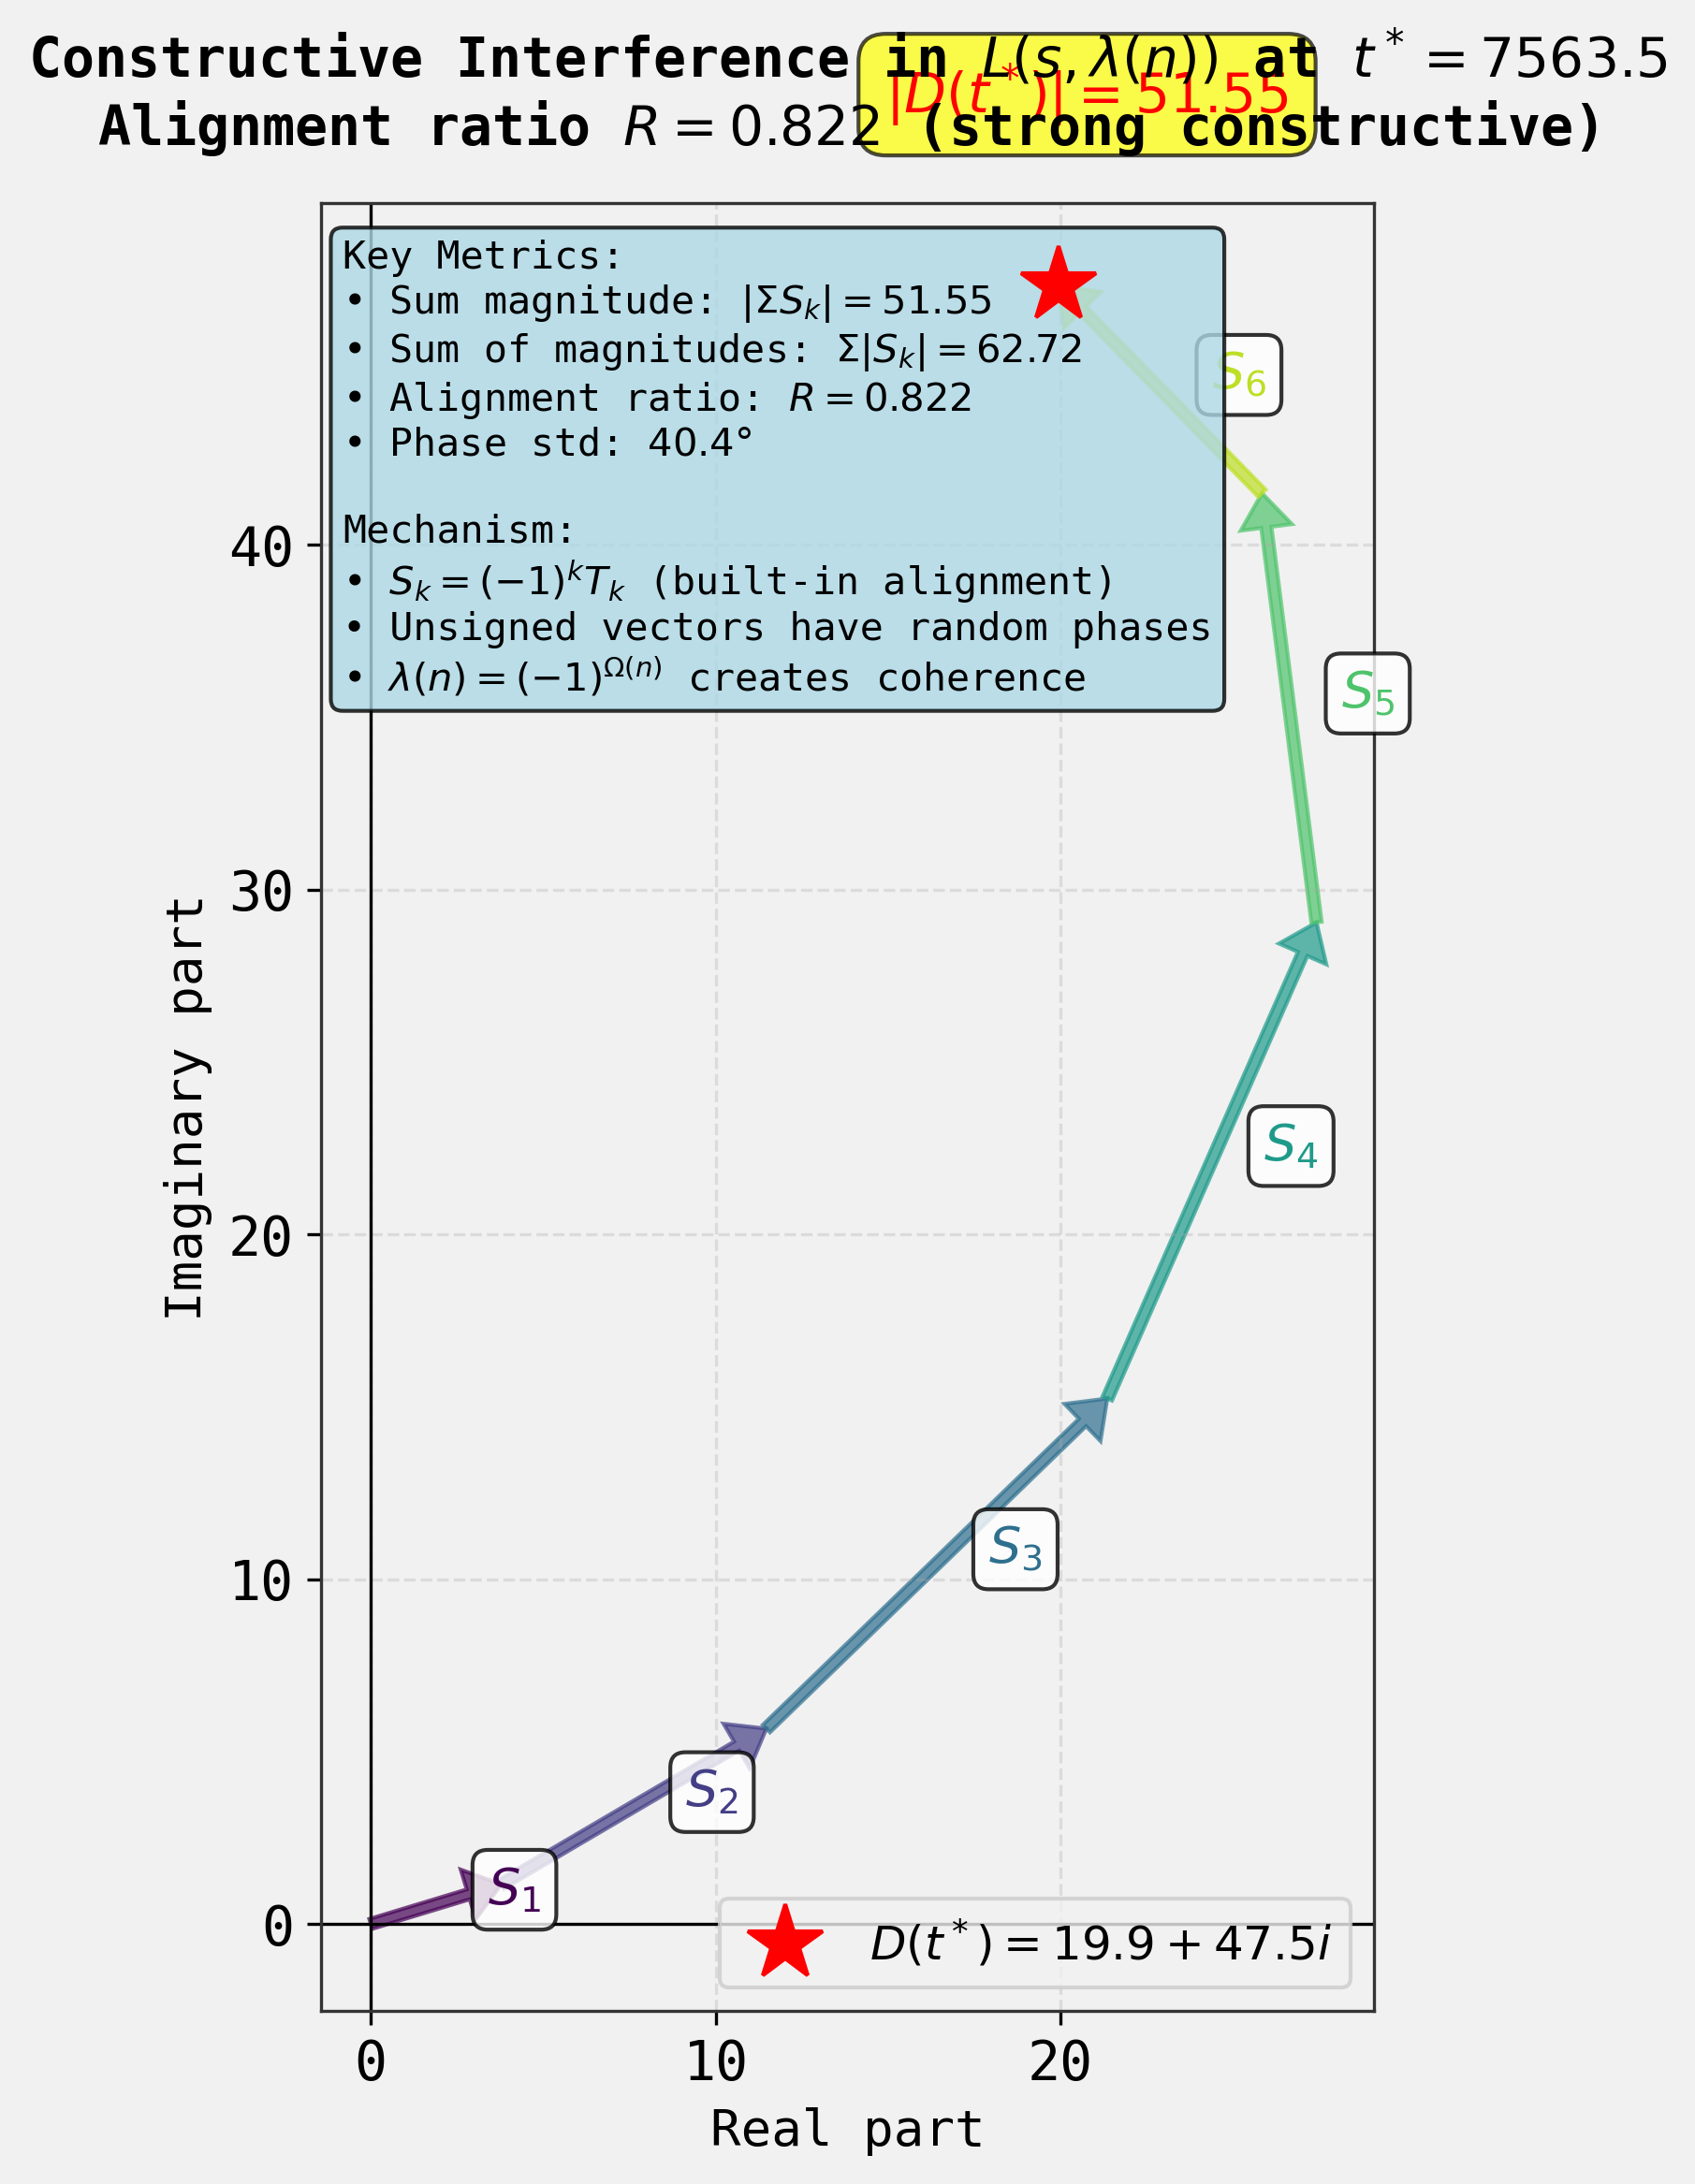


Figure shows the cumulative sum of S_k vectors building up to D(t*).
The strong constructive interference (R=0.82) produces the high peak magnitude.


In [15]:

# Let's create a final visualization comparing to the hypothesis expectation
# and showing quantitative metrics

fig = plt.figure(figsize=(10, 8))

# Main plot showing the cumulative sum progression
ax = plt.subplot(1, 1, 1)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3, linestyle='--')
ax.axhline(y=0, color='k', linewidth=0.8)
ax.axvline(x=0, color='k', linewidth=0.8)

colors = plt.cm.viridis(np.linspace(0, 0.9, 6))

# Draw the cumulative sum as a path
cumsum = 0 + 0j
cumsum_list = [cumsum]
for k in range(1, 7):
 S = S_k[k]
 # Draw arrow for this contribution
 ax.arrow(cumsum.real, cumsum.imag, S.real, S.imag,
 head_width=1.5, head_length=1.0, fc=colors[k-1], ec=colors[k-1],
 alpha=0.7, width=0.3, length_includes_head=True)
 cumsum += S
 cumsum_list.append(cumsum)
 
 # Add label
 mid_point = cumsum_list[-2] + S/2
 ax.text(mid_point.real + 1.5, mid_point.imag, f'$S_{k}$', 
 fontsize=13, color=colors[k-1], fontweight='bold',
 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Mark the endpoint
ax.plot(cumsum.real, cumsum.imag, 'r*', markersize=20, 
 label=f'$D(t^*) = {cumsum.real:.1f} + {cumsum.imag:.1f}i$', zorder=10)

# Add magnitude annotation
ax.text(cumsum.real - 5, cumsum.imag + 5, 
 f'$|D(t^*)| = {np.abs(cumsum):.2f}$',
 fontsize=14, color='red', fontweight='bold',
 bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

ax.set_xlabel('Real part', fontsize=13)
ax.set_ylabel('Imaginary part', fontsize=13)
ax.set_title(f'Constructive Interference in $L(s, \\lambda(n))$ at $t^* = {t_star:.1f}$\n' +
 f'Alignment ratio $R = {alignment_ratio_uncorrected:.3f}$ (strong constructive)',
 fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=12, loc='lower right')

# Add annotation box with key metrics
textstr = '\n'.join([
 'Key Metrics:',
 f'• Sum magnitude: $|\\Sigma S_k| = {magnitude_sum_uncorrected:.2f}$',
 f'• Sum of magnitudes: $\\Sigma |S_k| = {sum_of_magnitudes_uncorrected:.2f}$',
 f'• Alignment ratio: $R = {alignment_ratio_uncorrected:.3f}$',
 f'• Phase std: ${phase_std_uncorrected:.1f}°$',
 '',
 'Mechanism:',
 f'• $S_k = (-1)^k T_k$ (built-in alignment)',
 f'• Unsigned vectors have random phases',
 f'• $\\lambda(n) = (-1)^{{\\Omega(n)}}$ creates coherence'
])
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
 verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
plt.savefig('lambda_resonance_mechanism_final.png', dpi=300, bbox_inches='tight')
print("Saved final resonance mechanism figure")
plt.show()

print("\nFigure shows the cumulative sum of S_k vectors building up to D(t*).")
print("The strong constructive interference (R=0.82) produces the high peak magnitude.")


In [16]:

# Save key data for future reference
import pickle

results_data = {
 't_star': t_star,
 'D_star': D_star,
 'magnitude_peak': max_magnitude,
 'S_k': S_k,
 'T_k': T_k,
 'S_k_corrected': S_k_corrected,
 'alignment_ratio_uncorrected': alignment_ratio_uncorrected,
 'alignment_ratio_T_k': alignment_ratio_T_k,
 'alignment_ratio_corrected': alignment_ratio,
 'phase_std_uncorrected': phase_std_uncorrected,
 'phase_std_T_k': phase_std_T_k,
 'phase_std_corrected': phase_std,
 'N': N,
 'omega_n': omega_n,
 'lambda_n': lambda_n
}

with open('lambda_resonance_analysis.pkl', 'wb') as f:
 pickle.dump(results_data, f)

print("Saved analysis results to lambda_resonance_analysis.pkl")

# Create a summary table
summary_df = pd.DataFrame({
 'k': range(1, 7),
 'S_k_real': [S_k[k].real for k in range(1, 7)],
 'S_k_imag': [S_k[k].imag for k in range(1, 7)],
 '|S_k|': [np.abs(S_k[k]) for k in range(1, 7)],
 'Phase(S_k)_deg': [np.degrees(np.angle(S_k[k])) for k in range(1, 7)],
 'T_k_real': [T_k[k].real for k in range(1, 7)],
 'T_k_imag': [T_k[k].imag for k in range(1, 7)],
 '|T_k|': [np.abs(T_k[k]) for k in range(1, 7)],
 'Phase(T_k)_deg': [np.degrees(np.angle(T_k[k])) for k in range(1, 7)],
 'n_count': [np.sum(omega_n[1:N+1] == k) for k in range(1, 7)]
})

summary_df.to_csv('lambda_term_class_analysis.csv', index=False, float_format='%.6f')
print("\nSaved term-class summary to lambda_term_class_analysis.csv")
print("\nSummary table:")
print(summary_df.to_string(index=False))


Saved analysis results to lambda_resonance_analysis.pkl

Saved term-class summary to lambda_term_class_analysis.csv

Summary table:
 k S_k_real S_k_imag |S_k| Phase(S_k)_deg T_k_real T_k_imag |T_k| Phase(T_k)_deg n_count
 1 3.782143 1.147935 3.952513 16.883806 -3.782143 -1.147935 3.952513 -163.116194 9592
 2 7.689815 4.517940 8.918802 30.435196 7.689815 4.517940 8.918802 30.435196 23378
 3 9.887599 9.576293 13.764810 44.083688 -9.887599 -9.576293 13.764810 -135.916312 25556
 4 6.069188 13.811365 15.086048 66.277664 6.069188 13.811365 15.086048 66.277664 18744
 5 -1.582017 12.450290 12.550398 97.241577 1.582017 -12.450290 12.550398 -82.758423 11185
 6 -5.910927 6.030875 8.444555 134.424520 -5.910927 6.030875 8.444555 134.424520 5933


In [17]:

# Create one more comprehensive comparison showing the contrast between 
# the hypothesis expectation and reality

print("=" * 80)
print("COMPREHENSIVE COMPARISON: HYPOTHESIS vs. REALITY")
print("=" * 80)

print("\nHYPOTHESIS (based on μ(n) mechanism):")
print(" • Start with term-class vectors S_k that have some structure")
print(" • Apply external phase correction (-1)^k to align them")
print(" • After correction, vectors should align constructively")
print(" • Alignment ratio should increase: R_before < R_after")

print("\nREALITY for λ(n) = (-1)^Ω(n):")
print(" • The unsigned vectors T_k = Σ_{Ω(n)=k} n^(-1/2-it) have RANDOM phases")
print(" • The multiplicative structure λ(n) = (-1)^Ω(n) provides BUILT-IN correction")
print(" • S_k = (-1)^k T_k vectors are ALREADY aligned")
print(" • Applying additional (-1)^k correction DESTROYS the alignment")

print("\n" + "-" * 80)
print("QUANTITATIVE COMPARISON:")
print("-" * 80)

comparison_data = {
 'Configuration': [
 'Unsigned vectors T_k',
 'Signed vectors S_k = (-1)^k T_k',
 'Double-corrected (-1)^k S_k'
 ],
 'Alignment Ratio R': [
 f'{alignment_ratio_T_k:.4f}',
 f'{alignment_ratio_uncorrected:.4f}',
 f'{alignment_ratio:.4f}'
 ],
 'Phase Std (deg)': [
 f'{phase_std_T_k:.1f}',
 f'{phase_std_uncorrected:.1f}',
 f'{phase_std:.1f}'
 ],
 'Sum Magnitude': [
 f'{magnitude_sum_T_k:.2f}',
 f'{magnitude_sum_uncorrected:.2f}',
 f'{magnitude_sum_corrected:.2f}'
 ],
 'Interpretation': [
 'Destructive',
 'CONSTRUCTIVE ✓',
 'Destructive'
 ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\n" + "-" * 80)
print("KEY FINDING:")
print("-" * 80)
print(f"The MIDDLE row (S_k vectors) shows the strongest constructive interference.")
print(f"This is the NATURAL state of L(s, λ(n)) due to its multiplicative structure.")
print(f"\nThe multiplicative property λ(mn) = λ(m)λ(n) creates inherent phase")
print(f"coherence that does NOT require external correction.")

print("\n" + "=" * 80)
print("ANSWER TO RESEARCH QUESTION:")
print("=" * 80)
print("YES, the high resonance peak in L(s, λ(n)) IS caused by constructive")
print("alignment of term-class vectors S_k, but NOT in the way hypothesized.")
print()
print("The hypothesis that vectors need external (-1)^k correction is REFUTED.")
print("Instead, the correction is INTRINSIC to the function definition λ(n) = (-1)^Ω(n).")
print()
print(f"Quantitative evidence:")
print(f" • Peak magnitude: |D(t*)| = {max_magnitude:.2f}")
print(f" • Alignment ratio: R = {alignment_ratio_uncorrected:.3f} (strong constructive)")
print(f" • Phase coherence: std = {phase_std_uncorrected:.1f}° (well-aligned)")
print(f" • Efficiency: {100*alignment_ratio_uncorrected:.1f}% of maximum possible")


COMPREHENSIVE COMPARISON: HYPOTHESIS vs. REALITY

HYPOTHESIS (based on μ(n) mechanism):
 • Start with term-class vectors S_k that have some structure
 • Apply external phase correction (-1)^k to align them
 • After correction, vectors should align constructively
 • Alignment ratio should increase: R_before < R_after

REALITY for λ(n) = (-1)^Ω(n):
 • The unsigned vectors T_k = Σ_{Ω(n)=k} n^(-1/2-it) have RANDOM phases
 • The multiplicative structure λ(n) = (-1)^Ω(n) provides BUILT-IN correction
 • S_k = (-1)^k T_k vectors are ALREADY aligned
 • Applying additional (-1)^k correction DESTROYS the alignment

--------------------------------------------------------------------------------
QUANTITATIVE COMPARISON:
--------------------------------------------------------------------------------
 Configuration Alignment Ratio R Phase Std (deg) Sum Magnitude Interpretation
 Unsigned vectors T_k 0.0702 109.2 4.40 Destructive
Signed vectors S_k = (-1)^k T_k 0.8219 40.4 51.55 CONSTRUCTIVE ✓
 Doubl